<a href="https://colab.research.google.com/github/bhalleaheesha/Data-Analyst-Projects/blob/main/Energy_Price_Trends_%26_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose


# Load dataset
df = pd.read_csv('/content/Energy Pricing Timeseries Updated.csv')

In [11]:
df.columns

Index(['id', 'price_date', 'price_off_peak_var', 'price_peak_var',
       'price_mid_peak_var', 'price_off_peak_fix', 'price_peak_fix',
       'price_mid_peak_fix', 'Unnamed: 8'],
      dtype='object')

In [8]:
df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix,Unnamed: 8
0,1031,01-01-2015,0.151367,0.103395,0.071536,44.266931,24.339581,16.226389,NaN
1,1032,01-02-2015,0.151367,0.103395,0.071536,44.266931,24.339581,16.226389,NaN
2,1033,01-03-2015,0.151367,0.103395,0.071536,44.266931,24.339581,16.226389,NaN
3,1034,01-04-2015,0.149626,0.103395,0.071536,44.266931,24.339581,16.226389,NaN
4,1035,01-05-2015,0.149626,0.103395,0.071536,44.266931,24.339581,16.226389,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


In [19]:
df['price_date'] = pd.to_datetime(df['price_date'], errors='coerce')
df.drop(columns=['Unnamed: 8'], inplace=True, errors='ignore')

In [21]:
df = df.sort_values('price_date')

In [22]:
df.isnull().sum()

,0
id,0
price_date,0
price_off_peak_var,0
price_peak_var,0
price_mid_peak_var,0
price_off_peak_fix,0
price_peak_fix,0
price_mid_peak_fix,0


In [27]:
price_cols = [
    'price_off_peak_var',
    'price_peak_var',
    'price_mid_peak_var',
    'price_off_peak_fix',
    'price_peak_fix',
    'price_mid_peak_fix'
]

df['avg_price'] = df[price_cols].mean(axis=1)

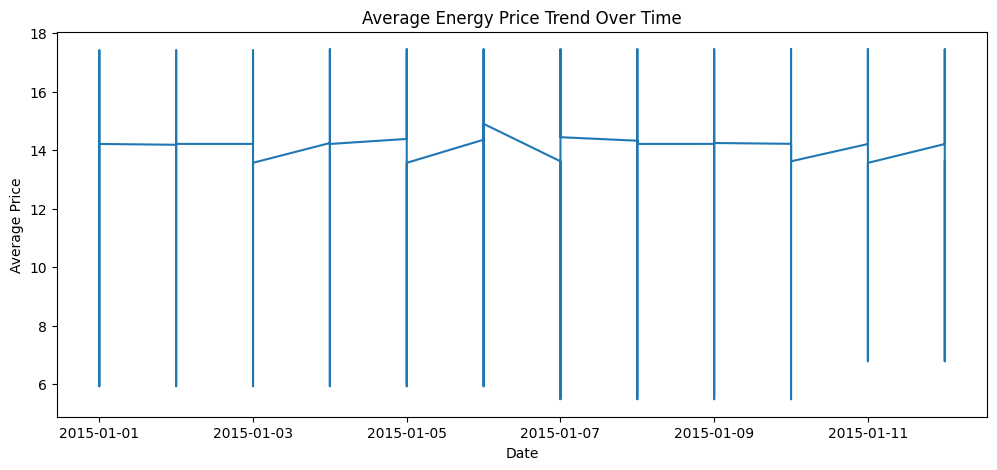

In [28]:
plt.figure(figsize=(12,5))
plt.plot(df['price_date'], df['avg_price'])
plt.title('Average Energy Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Average Price')
plt.show()

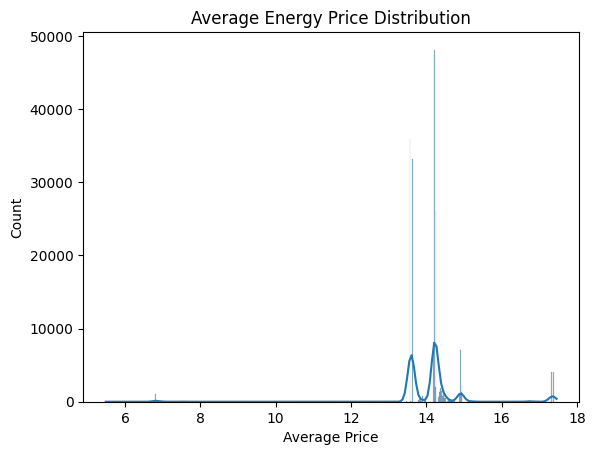

In [30]:
sns.histplot(df['avg_price'], kde=True)
plt.title('Average Energy Price Distribution')
plt.xlabel('Average Price')
plt.show()

**Time Series Analysis**

In [33]:
df.sort_values('price_date', inplace=True)

In [34]:
df['rolling_30_days'] = df['avg_price'].rolling(window=30).mean()

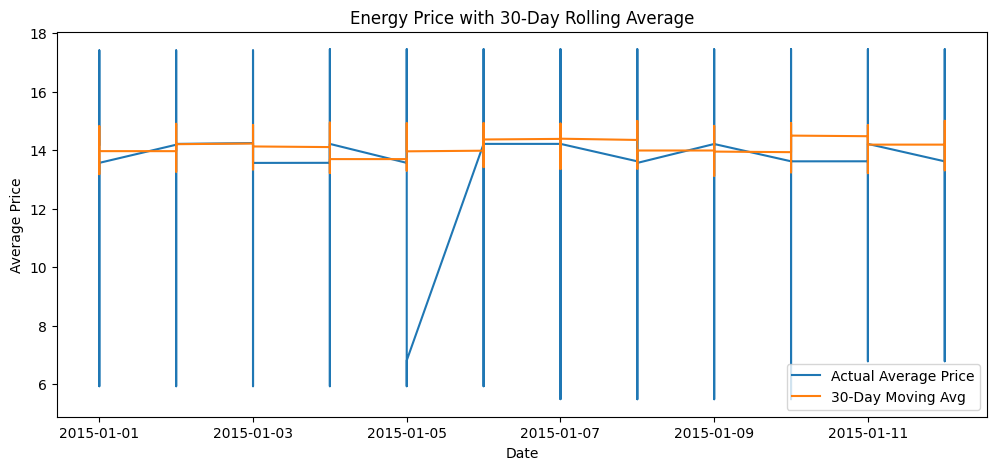

In [35]:
plt.figure(figsize=(12,5))
plt.plot(df['price_date'], df['avg_price'], label='Actual Average Price')
plt.plot(df['price_date'], df['rolling_30_days'], label='30-Day Moving Avg')
plt.legend()
plt.title('Energy Price with 30-Day Rolling Average')
plt.xlabel('Date')
plt.ylabel('Average Price')
plt.show()

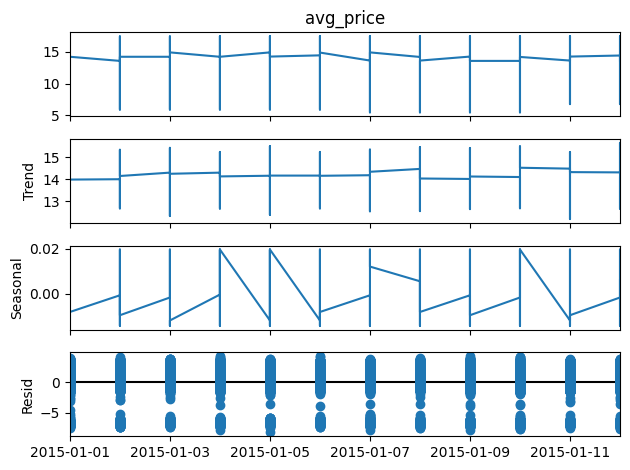

In [37]:
#Seasonality Decomposition
df.sort_values('price_date', inplace=True)
df.set_index('price_date', inplace=True)

from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(
    df['avg_price'],
    model='additive',
    period=12
)

decomposition.plot()
plt.show()

**Volatility Analysis**

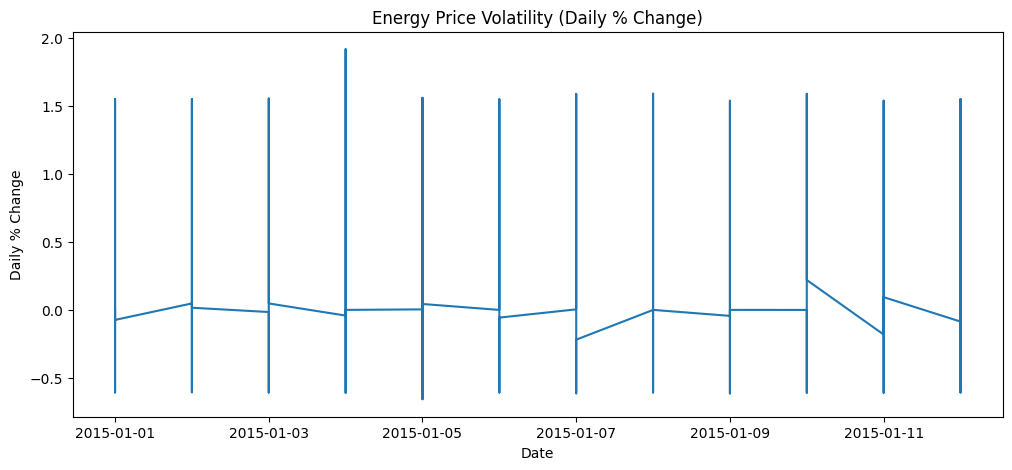

In [40]:
df.sort_index(inplace=True)

df['daily_change'] = df['avg_price'].pct_change()

plt.figure(figsize=(12,5))
plt.plot(df.index, df['daily_change'])
plt.title('Energy Price Volatility (Daily % Change)')
plt.xlabel('Date')
plt.ylabel('Daily % Change')
plt.show()

**Simple Forecasting (Moving Average Method)**

In [47]:
forecast = df['avg_price'].rolling(7).mean().iloc[-1]
forecast

np.float64(13.924182806666666)

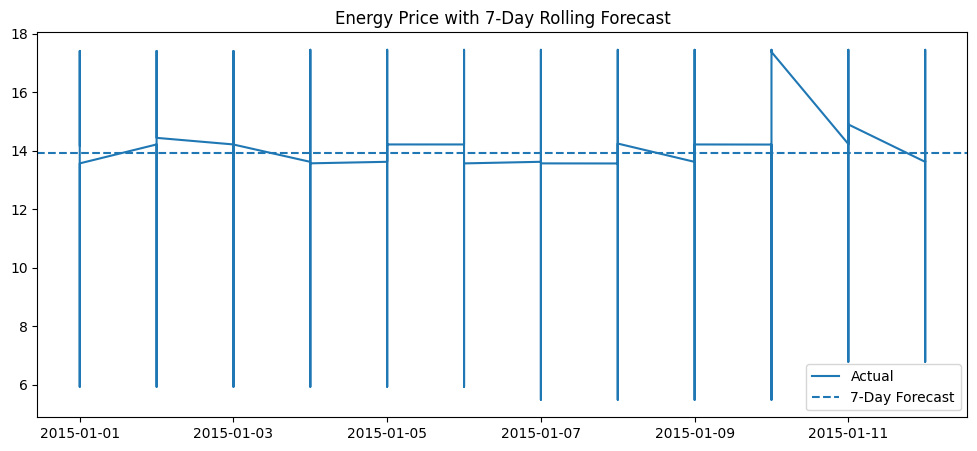

In [48]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['avg_price'], label='Actual')
plt.axhline(forecast, linestyle='--', label='7-Day Forecast')
plt.legend()
plt.title('Energy Price with 7-Day Rolling Forecast')
plt.show()

**Advanced KPIs & Metrics**

In [49]:
kpis = {
    'Average Price': df['avg_price'].mean(),
    'Maximum Price': df['avg_price'].max(),
    'Minimum Price': df['avg_price'].min(),
    'Price Standard Deviation (Volatility)': df['avg_price'].std(),
    'Average Daily Change (%)': df['daily_change'].mean() * 100
}

kpi_df = pd.DataFrame(list(kpis.items()), columns=['Metric', 'Value'])
kpi_df

,Metric,Value
0,Average Price,14.138028
1,Maximum Price,17.458000
2,Minimum Price,5.488555
3,Price Standard Deviation (Volatility),1.014069
4,Average Daily Change (%),0.688147


**Additional Visualizations**

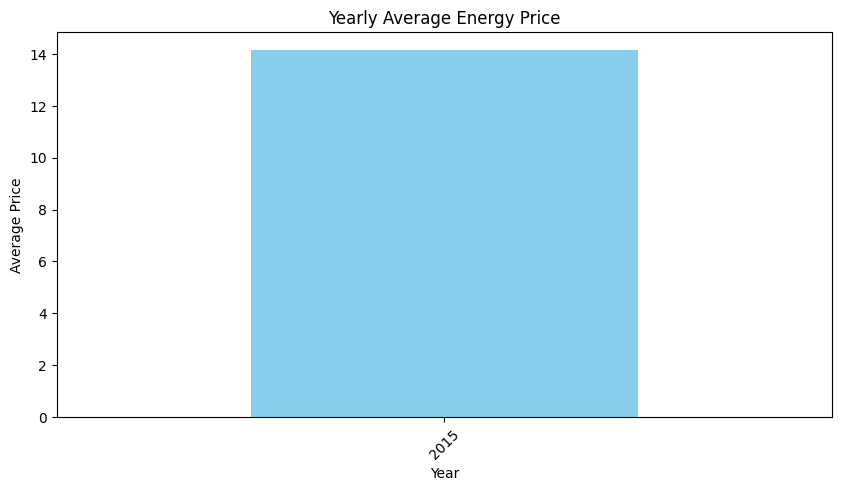

In [54]:
#Yearly Price Comparison

# Ensure date column is present
df = df.reset_index()  # only if price_date is currently the index
# Extract year
df['Year'] = df['price_date'].dt.year
# Group by year and calculate average price
yearly_avg = df.groupby('Year')['avg_price'].mean()
# Plot
yearly_avg.plot(kind='bar', figsize=(10,5), color='skyblue')
plt.title('Yearly Average Energy Price')
plt.xlabel('Year')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()


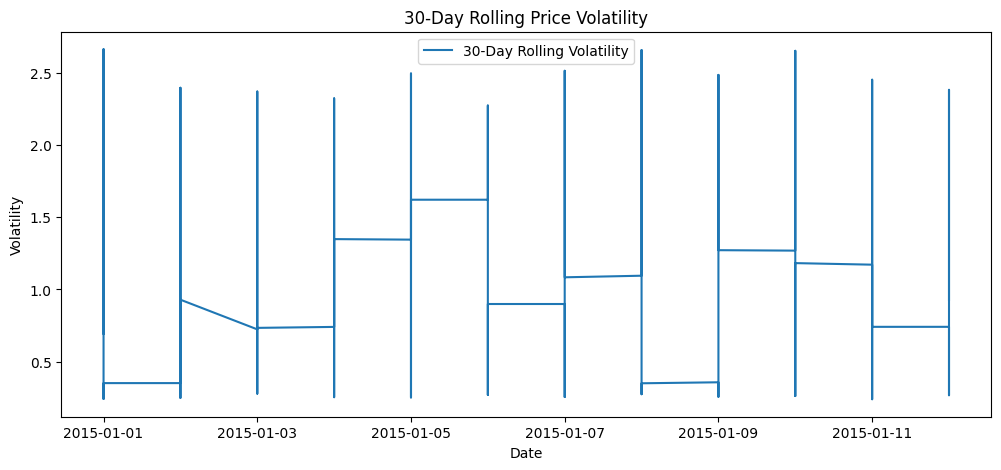

In [55]:
#Rolling Volatility (30-Day Standard Deviation)

#Option 1: price_date is a column
# Calculate 30-day rolling volatility
df['Rolling_Volatility'] = df['avg_price'].rolling(30).std()

# Plot
plt.figure(figsize=(12,5))
plt.plot(df['price_date'], df['Rolling_Volatility'], label='30-Day Rolling Volatility')
plt.title('30-Day Rolling Price Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.show()

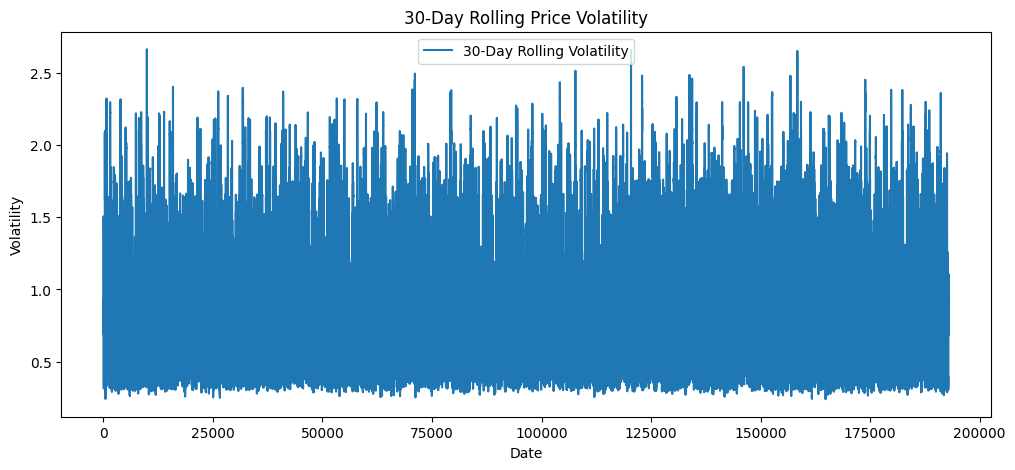

In [56]:
#Rolling Volatility (30-Day Standard Deviation)
#Option 2: price_date is the index

# Calculate 30-day rolling volatility
df['Rolling_Volatility'] = df['avg_price'].rolling(30).std()
# Plot using index
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Rolling_Volatility'], label='30-Day Rolling Volatility')
plt.title('30-Day Rolling Price Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.show()


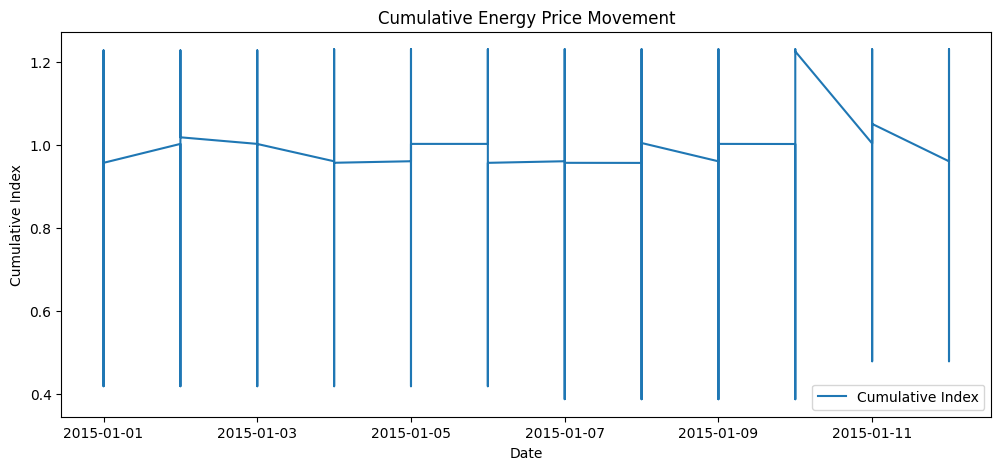

In [57]:
#Cumulative Price Movement

#Option 1: price_date is a column
#Calculate cumulative return
df['Cumulative_Return'] = (1 + df['daily_change']).cumprod()
# Plot
plt.figure(figsize=(12,5))
plt.plot(df['price_date'], df['Cumulative_Return'], label='Cumulative Index')
plt.title('Cumulative Energy Price Movement')
plt.xlabel('Date')
plt.ylabel('Cumulative Index')
plt.legend()
plt.show()

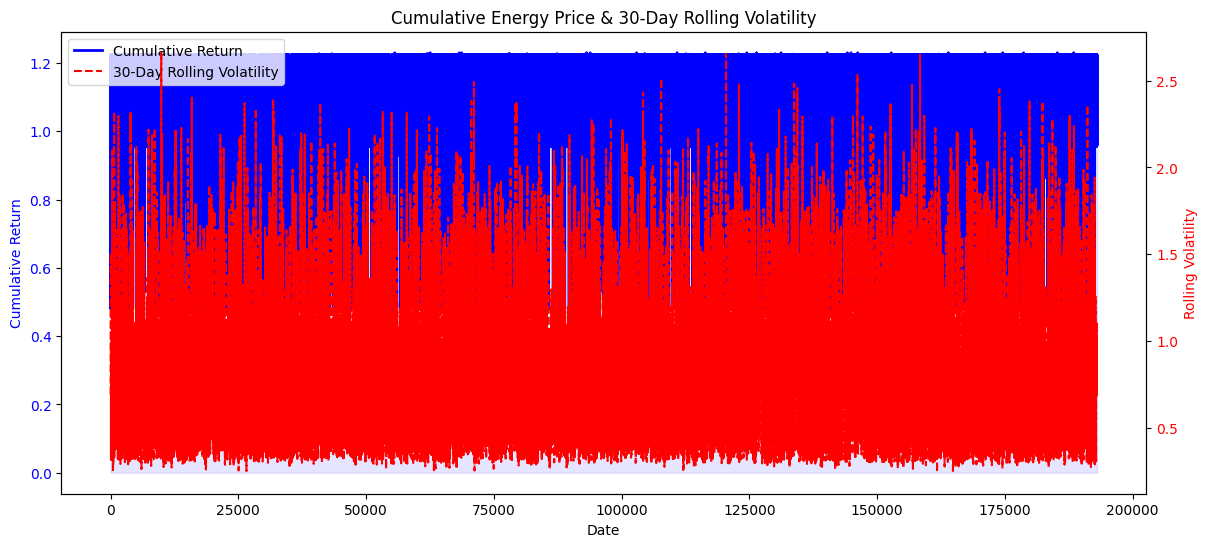

In [64]:
#Cumulative Price Movement

#Option 2: price_date is the index
#Calculate cumulative return
df['Cumulative_Return'] = (1 + df['daily_change']).cumprod()

# Plot using index
# Ensure rolling volatility exists
df['Rolling_Volatility'] = df['avg_price'].rolling(30).std()

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(14,6))

# Plot cumulative return on primary y-axis
ax1.plot(df.index, df['Cumulative_Return'], color='blue', label='Cumulative Return', linewidth=2)
ax1.fill_between(df.index, df['Cumulative_Return'], color='blue', alpha=0.1)
ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative Return', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary y-axis for rolling volatility
ax2 = ax1.twinx()
ax2.plot(df.index, df['Rolling_Volatility'], color='red', linestyle='--', label='30-Day Rolling Volatility')
ax2.set_ylabel('Rolling Volatility', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title('Cumulative Energy Price & 30-Day Rolling Volatility')
plt.show()

